# Customer Segmentation - Online Retail Dataset
Segmentasi customer menggunakan RFM Analysis (Recency, Frequency, Monetary) dan K-Means Clustering.
Link dataset : https://archive.ics.uci.edu/dataset/352/online+retail

## 1. Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset
Kalau di Google Colab, upload file `Online_Retail.xlsx` dulu atau mount Google Drive.

In [6]:
# Jika pakai Google Colab, uncomment untuk upload file manual
from google.colab import files
uploaded = files.upload()

df = pd.read_excel("Online_Retail.xlsx")
print(df.shape)
df.head()

Saving Online_Retail.xlsx to Online_Retail.xlsx
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3. Data Cleaning
- Hapus baris dengan `CustomerID` kosong (tidak bisa dipakai untuk segmentasi per customer)
- Hapus transaksi cancel (InvoiceNo diawali 'C')
- Hapus `Quantity` dan `UnitPrice` yang negatif atau nol

In [7]:
df_clean = df.copy()

# Buang CustomerID kosong
df_clean = df_clean.dropna(subset=["CustomerID"])

# Buang invoice yang dibatalkan (kode invoice diawali huruf C)
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

# Buang Quantity dan UnitPrice yang tidak valid
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

print("Jumlah baris sebelum cleaning:", len(df))
print("Jumlah baris sesudah cleaning:", len(df_clean))

Jumlah baris sebelum cleaning: 541909
Jumlah baris sesudah cleaning: 397884


## 4. Feature Engineering - RFM
- **Recency**: berapa hari sejak transaksi terakhir customer
- **Frequency**: jumlah invoice unik per customer
- **Monetary**: total belanja per customer

In [8]:
df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Tanggal acuan = 1 hari setelah transaksi terakhir di dataset
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


## 5. Eksplorasi Distribusi RFM

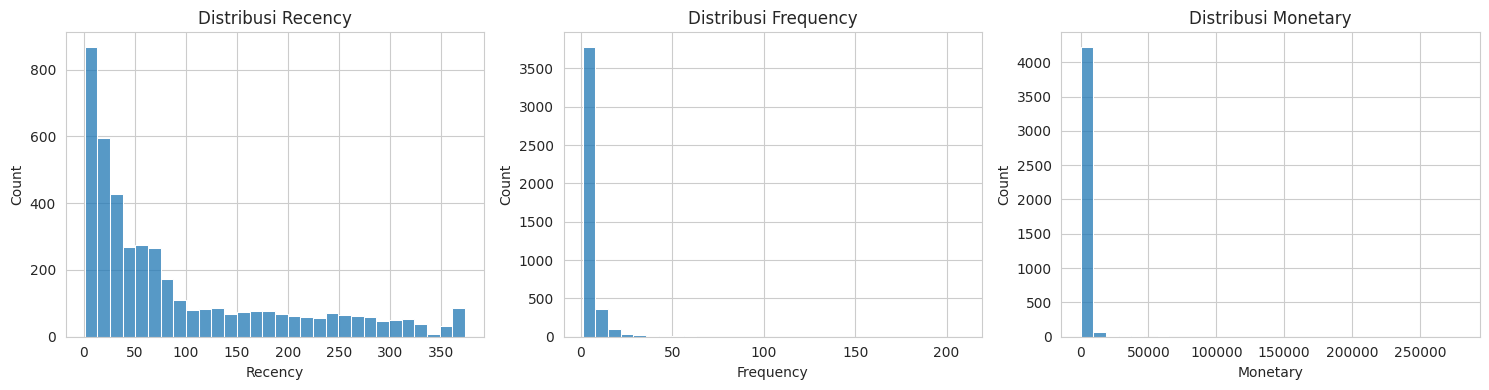

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Distribusi Recency")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Distribusi Frequency")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Distribusi Monetary")

plt.tight_layout()
plt.show()

rfm[["Recency", "Frequency", "Monetary"]].describe()

## 6. Handling Outlier & Scaling
Monetary dan Frequency biasanya sangat skewed, jadi dipangkas dengan batas persentil sebelum scaling.

In [10]:
# Cap outlier di persentil 99 supaya clustering tidak didominasi outlier ekstrem
for col in ["Frequency", "Monetary"]:
    cap = rfm[col].quantile(0.99)
    rfm[col] = np.where(rfm[col] > cap, cap, rfm[col])

rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

## 7. Menentukan Jumlah Cluster Optimal (Elbow Method + Silhouette Score)

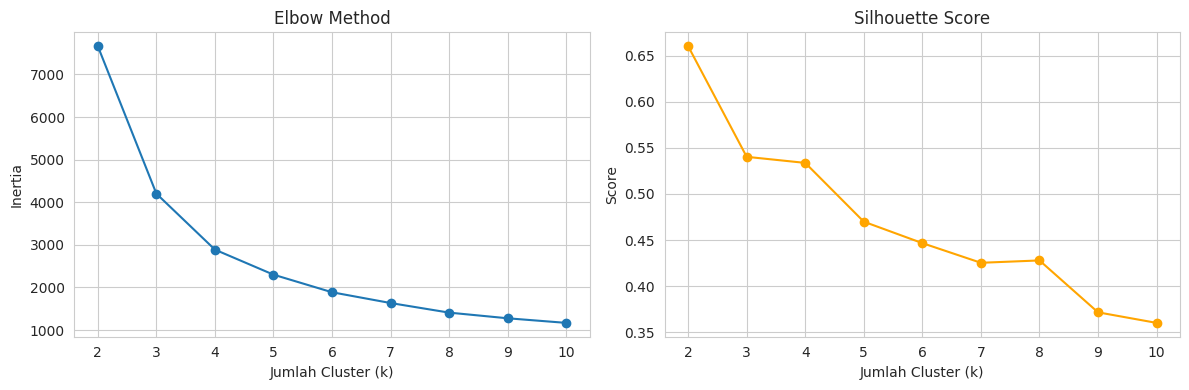

In [11]:
inertia = []
silhouette = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

## 8. Training K-Means
Ganti `optimal_k` sesuai hasil elbow/silhouette di atas.

In [12]:
optimal_k = 4  # sesuaikan berdasarkan grafik elbow & silhouette

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm["Cluster"].value_counts().sort_index()

,count
Cluster,
0,2620
1,574
2,1035
3,109


## 9. Profiling & Interpretasi Cluster

In [13]:
cluster_summary = rfm.groupby("Cluster").agg(
    Recency_mean=("Recency", "mean"),
    Frequency_mean=("Frequency", "mean"),
    Monetary_mean=("Monetary", "mean"),
    Jumlah_Customer=("CustomerID", "count")
).reset_index()

cluster_summary

,Cluster,Recency_mean,Frequency_mean,Monetary_mean,Jumlah_Customer
0,0,48.457634,2.744656,914.230845,2620
1,1,22.297909,10.557491,4230.625523,574
2,2,250.889855,1.508213,441.670098,1035
3,3,18.293578,23.651376,15172.758998,109


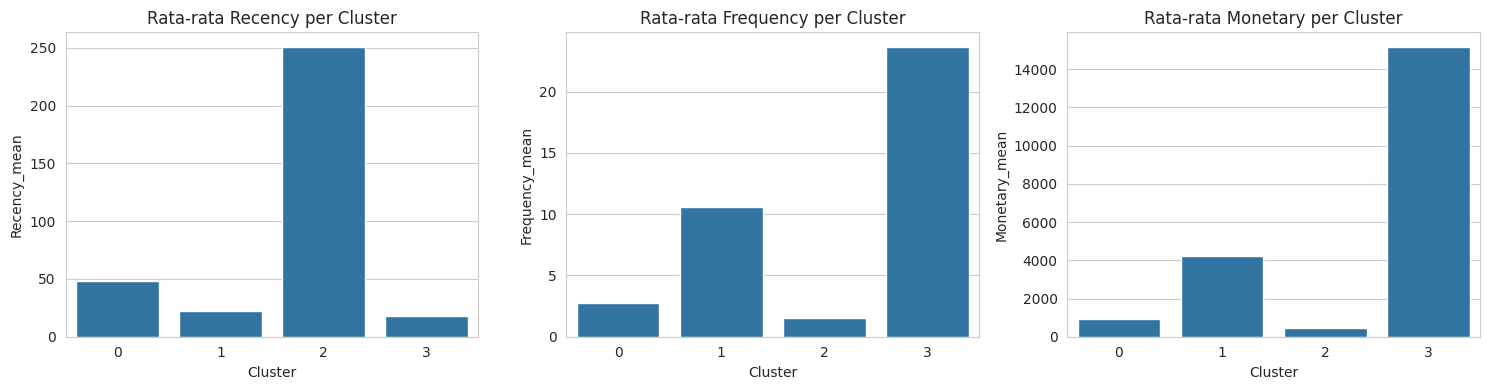

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=cluster_summary, x="Cluster", y="Recency_mean", ax=axes[0])
axes[0].set_title("Rata-rata Recency per Cluster")

sns.barplot(data=cluster_summary, x="Cluster", y="Frequency_mean", ax=axes[1])
axes[1].set_title("Rata-rata Frequency per Cluster")

sns.barplot(data=cluster_summary, x="Cluster", y="Monetary_mean", ax=axes[2])
axes[2].set_title("Rata-rata Monetary per Cluster")

plt.tight_layout()
plt.show()

## 10. Visualisasi Cluster (2D)
Visualisasi menggunakan Frequency vs Monetary, warna berdasarkan cluster.

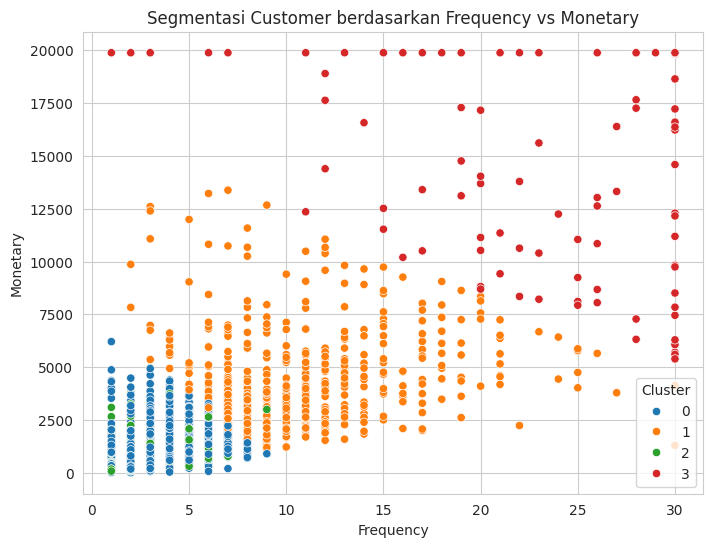

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="tab10")
plt.title("Segmentasi Customer berdasarkan Frequency vs Monetary")
plt.show()

## 11. Penamaan Segmen (Opsional)
Sesuaikan label berikut dengan karakteristik cluster hasil `cluster_summary` di atas. Contoh pola umum:
- Recency rendah, Frequency & Monetary tinggi -> Customer Loyal/Champion
- Recency tinggi, Frequency & Monetary rendah -> Customer Churn/At Risk
- Recency rendah, Frequency & Monetary rendah -> Customer Baru
- Recency sedang, Frequency & Monetary sedang -> Customer Potensial

In [16]:
label_map = {
    0: "Segmen 0",
    1: "Segmen 1",
    2: "Segmen 2",
    3: "Segmen 3",
}

rfm["Segment"] = rfm["Cluster"].map(label_map)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1.0,19880.9957,3,Segmen 3
1,12347,2,7.0,4310.0000,1,Segmen 1
2,12348,75,4.0,1797.2400,0,Segmen 0
3,12349,19,1.0,1757.5500,0,Segmen 0
4,12350,310,1.0,334.4000,2,Segmen 2


## 12. Simpan Hasil

In [17]:
rfm.to_csv("customer_segmentation_result.csv", index=False)
print("Hasil disimpan ke customer_segmentation_result.csv")

Hasil disimpan ke customer_segmentation_result.csv
